In [9]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [10]:
def simulate_one_count(sample_size):
    return sum(np.random.choice(['H', 'T'], sample_size) == 'H')

simulate_one_count(200)

98

In [11]:
num_simulations = 1000
counts = make_array()
for i in np.arange(num_simulations):
    counts = np.append(counts, simulate_one_count(200))

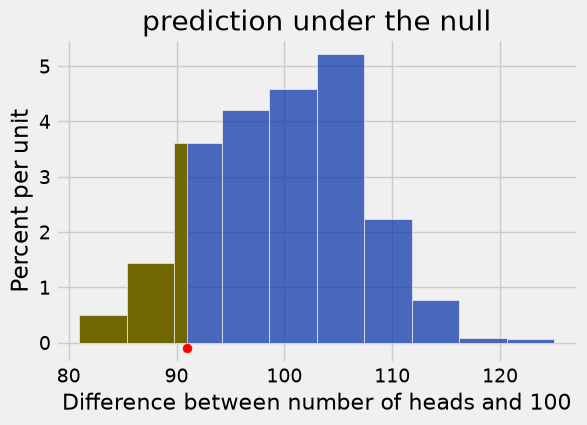

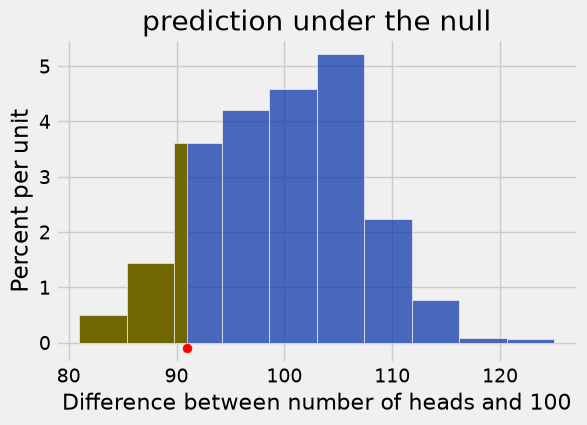

In [12]:
trials = Table().with_column('Difference between number of heads and 100', counts)
trials.hist(right_end = 91)
plt.scatter(91, -.001, color = 'red', s=40)
plt.title('prediction under the null')

plot_trials(counts)

In [13]:
np.count_nonzero(counts <= 91)/len(counts)

0.13400000000000001

## conclusion

we have failed to reject the null hypothesis

In [14]:
# Put it all together
def run_test(num_simulations, sample_size):
    num_simulations = 10000
    counts = make_array()
    for i in np.arange(num_simulations):
        counts = np.append(counts, simulate_one_count(sample_size))
    return counts

counts = run_test(1000, 200)
counts

array([  88.,   94.,  100., ...,  101.,   97.,  102.])

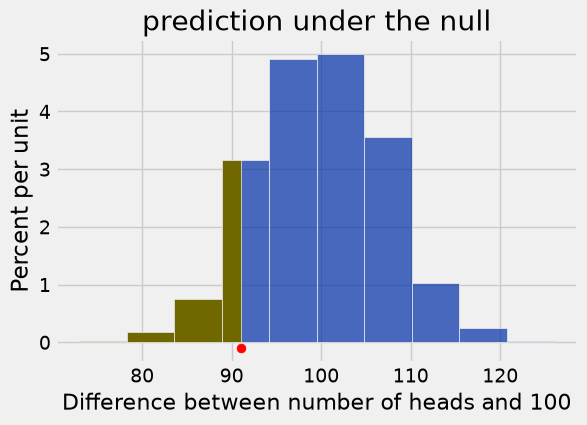

In [15]:
plot_trials(counts)

In [16]:
# suppose that the unknown true proportion is 0.5
true_proportion = 0.5 
true_distribution = make_array(true_proportion, 1 - true_proportion)

In [17]:
# Taste test woth 200 people 
sample_size = 200
sample_proportions(sample_size, true_distribution) * sample_size

array([  91.,  109.])

In [18]:
def run_experiment(num_simulations, sample_size, true_proportions):
    true_distribution = make_array(true_proportion, 1 - true_proportion)
    taste_test_results = sample_proportions(sample_size, true_distribution) * sample_size
    observed_stats_from_sample = taste_test_results.item(0)

    counts = run_test(num_simulations, sample_size)
    pvalue = np.average(counts <= observed_stats_from_sample)
    return pvalue

run_experiment(1000, 200, .5)

0.53010000000000002

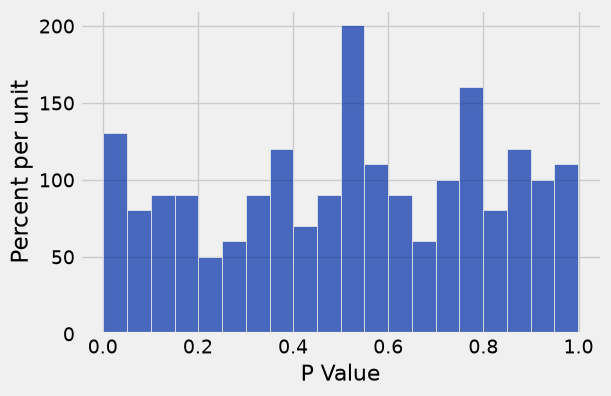

In [19]:
p_values = make_array()
for p in np.arange(200):
    p_value = run_experiment(100, sample_size, true_proportion)
    p_values = np.append(p_values, p_value)

Table().with_column('P Value', p_values).hist(0, bins = 20)